# **Validacion: Definir Poblacion de inactivos** 

In [1]:
# --- librerias --- #

import pandas as pd
import numpy as np
import os

from pathlib import Path

# --- set cwd --- #
ROOT = Path().cwd().parent
os.chdir(ROOT)

In [2]:
# --- Leemos las bases --- #

labels = (
    pd.read_parquet(
        r'data\raw\labels\labes_17-09-2026.parquet', 
        engine='pyarrow',
    )
)

demografica = (
    pd.read_parquet(
        r'data\raw\features\Demografica_23-09-2026.parquet', 
        engine='pyarrow', 
    )
)


In [3]:
labels.head()

,strPeriodo,strIdentificacion,strEstadoInicial,IndicadorReactivado
0,202507,51865780,14,0
1,202507,1069432206,14,0
2,202507,1036621602,14,0
3,202507,1143415763,14,0
4,202507,1013609840,14,0


In [4]:
demografica.head()

,strIdentificacion,demo_Tipo_Documento,demo_Tipo_Vinculacion,demo_Estado_Civil,demo_Personas_a_Cargo,demo_Personas_a_Cargo_Menores_18,demo_Sexo,demo_Estrato,demo_Nombre_Tipo_Vivienda,demo_Nombre_Nivel_Academico,...,demo_Egresos,demo_Nombre_Ocupacion,demo_Ptaje_acierta,demo_Cuotas_canceladas_aportes,demo_Saldoaportes,demo_Segmento_Ciclo_de_Vida,demo_Edad,demo_Antiguedad,demo_suma_productos,strPeriodo
0,134386,CE,Mayor 60,Casado,0.0,0.0,F,9,Desconocida,Ninguno,...,1125000.0,Asalariado,0.0,NaN,NaN,Maduro,80.0,30.68,0.0,202507
1,140996,CC,Mayor 60,Soltero,0.0,0.0,M,3,Familiar,Técnico,...,1125000.0,Pensionado - Jubilado,495.0,42.0,1762913.0,Maduro,90.0,8.38,2.0,202507
2,223545,CE,Profesional,Casado,0.0,0.0,F,6,Familiar,Profesional,...,4500000.0,Independiente,0.0,215.0,3380479.0,Transicion,54.0,23.35,1.0,202507
3,392226,CE,Profesional,Casado,0.0,0.0,F,6,Familiar,Profesional,...,1125000.0,Independiente,610.0,23.0,904141.0,Mujer Independiente,38.0,9.43,0.0,202507
4,429809,CE,Profesional,Soltero,0.0,0.0,M,3,Familiar,Profesional,...,NaN,Independiente,544.0,10.0,608000.0,Transicion,43.0,2.01,0.0,202507


In [5]:
# --- merge --- #

df = (
    labels
    .merge(
        demografica, 
        how='left', 
        on=['strIdentificacion','strPeriodo'], 
    )
)

df.head()

,strPeriodo,strIdentificacion,strEstadoInicial,IndicadorReactivado,demo_Tipo_Documento,demo_Tipo_Vinculacion,demo_Estado_Civil,demo_Personas_a_Cargo,demo_Personas_a_Cargo_Menores_18,demo_Sexo,...,demo_Ingresos,demo_Egresos,demo_Nombre_Ocupacion,demo_Ptaje_acierta,demo_Cuotas_canceladas_aportes,demo_Saldoaportes,demo_Segmento_Ciclo_de_Vida,demo_Edad,demo_Antiguedad,demo_suma_productos
0,202507,51865780,14,0,CC,Personas Jurídicas,Soltero,0.0,0.0,F,...,32025200.0,NaN,Independiente,803.0,17.0,1056000.0,Transicion,58.0,2.06,4.0
1,202507,1069432206,14,0,CC,Técnicos y Tecnólogos,Soltero,0.0,2.0,F,...,2000000.0,NaN,Independiente,744.0,3.0,75000.0,Consolidacion,40.0,3.32,0.0
2,202507,1036621602,14,0,CC,Profesional,Soltero,0.0,0.0,F,...,2250000.0,1125000.0,Asalariado,495.0,5.0,199252.0,Mujer Independiente,37.0,8.14,0.0
3,202507,1143415763,14,0,CC,Profesional,Soltero,0.0,0.0,F,...,1125000.0,1125000.0,Otro tipo de Actividad,579.0,2.0,4840.0,Joven Asociado,25.0,6.62,0.0
4,202507,1013609840,14,0,CC,Técnicos y Tecnólogos,Soltero,0.0,0.0,F,...,2105937.0,1737887.0,Asalariado,709.0,2.0,61500.0,Mujer Independiente,35.0,1.59,0.0


In [6]:
df['demo_Tipo_Documento'].value_counts()

demo_Tipo_Documento
CC     975634
NIT     18498
CE       3568
PS        118
SI         16
PPT        11
TI          2
Name: count, dtype: int64

In [7]:
# --- zoom a los NITs --- #

df[df['demo_Tipo_Documento']=='NIT']['IndicadorReactivado'].value_counts(normalize=True)*100

IndicadorReactivado
0    99.594551
1     0.405449
Name: proportion, dtype: float64

In [8]:
# --- Estado Base Label --- #
df['IndicadorReactivado'].value_counts(normalize=True)*100

IndicadorReactivado
0    98.259152
1     1.740848
Name: proportion, dtype: float64

In [13]:
# --- Menos de 6 cuotas pagadas --- #

MENOS_6C= df[df['demo_Cuotas_canceladas_aportes'].fillna(0) < 6].shape[0]

print(f'Total panel: {MENOS_6C}')
print(f'Promedio x mes: {MENOS_6C/12}')

Total panel: 395459
Promedio x mes: 32954.916666666664


In [14]:
# --- ratio de reactivacion: Malas Vinculacion en 1 año de historia ---#
df[df['demo_Cuotas_canceladas_aportes']>6]['IndicadorReactivado'].value_counts(normalize=True)*100

IndicadorReactivado
0    97.4756
1     2.5244
Name: proportion, dtype: float64

In [15]:
# --- Ratio(cuotas_pagas vs antiguedad) --- #

df['fe_cuotas_pagas_vs_antiguedad'] = (
    np.where(
        df['demo_Antiguedad'].fillna(0) > 0, 
        df['demo_Cuotas_canceladas_aportes'] / (df['demo_Antiguedad']*12)*100, 
        0
    )
    .round(2)
)

# --- Validar distribucion de la columna nueva --- #

df['fe_cuotas_pagas_vs_antiguedad'].describe()

count    997729.000000
mean         28.398724
std          25.502968
min          -3.680000
25%           7.840000
50%          18.660000
75%          43.570000
max         132.980000
Name: fe_cuotas_pagas_vs_antiguedad, dtype: float64

In [17]:
df[df['fe_cuotas_pagas_vs_antiguedad'] >= 100][['strPeriodo','strIdentificacion','demo_Antiguedad','demo_Cuotas_canceladas_aportes']].head()

,strPeriodo,strIdentificacion,demo_Antiguedad,demo_Cuotas_canceladas_aportes
11581,202507,22731855,0.73,9.0
12833,202507,60314669,17.22,207.0
39734,202507,1143869947,4.42,54.0
47869,202507,1233496629,1.72,22.0
119466,202508,1117528876,1.10,14.0


In [64]:
df[df['fe_cuotas_pagas_vs_antiguedad'] >= 100].shape[0]

40

In [65]:
# --- Validar tasa de reactivacion x deciles --- #
## --- Particionar x deciles --- # 
df['q'] = (
    pd.qcut(
        df['fe_cuotas_pagas_vs_antiguedad'], 
        10,
    )
)

# --- Validar tasa de reactivacion x cuantiles --- #

df.groupby(
    'q'
).agg(
    tasa_reactivacion = ('IndicadorReactivado', lambda s: (s == 1).mean()*100)
)

,tasa_reactivacion
q,
"(-3.681, 3.99]",0.682563
"(3.99, 6.44]",0.809173
"(6.44, 9.36]",0.871173
"(9.36, 13.23]",0.869946
"(13.23, 18.66]",0.900276
"(18.66, 26.42]",0.927769
"(26.42, 36.97]",1.076810
"(36.97, 51.28]",1.418007
"(51.28, 70.73]",2.659414


In [76]:
# --- filtrando x ejemplo: cuotas pagas >= 20% --- #

df[df['fe_cuotas_pagas_vs_antiguedad']>=20]['IndicadorReactivado'].value_counts(normalize=True)*100

IndicadorReactivado
0    97.268394
1     2.731606
Name: proportion, dtype: float64

In [79]:
# --- Escenario con < 20% de cuotas pagas --- #
print(df[df['fe_cuotas_pagas_vs_antiguedad']>=20]['IndicadorReactivado'].shape[0])
print(df[df['fe_cuotas_pagas_vs_antiguedad']>=20]['IndicadorReactivado'].value_counts(normalize=True)*100)

477924
IndicadorReactivado
0    97.268394
1     2.731606
Name: proportion, dtype: float64


In [80]:
print(df[df['demo_Cuotas_canceladas_aportes'].fillna(0) > 6].shape[0])
print(df[df['demo_Cuotas_canceladas_aportes']>=6]['IndicadorReactivado'].value_counts(normalize=True)*100)

557281
IndicadorReactivado
0    97.590921
1     2.409079
Name: proportion, dtype: float64


In [54]:
df[df['fe_cuotas_pagas_vs_antiguedad']>50].shape

(206200, 25)

In [82]:

def perfil_por_cuantil(
    df: pd.DataFrame,
    feature: str,
    target: str = "IndicadorReactivado",
    q: int = 10,
) -> pd.DataFrame:
    """
    Parte la feature en q grupos de igual tamaño y calcula, por grupo:
      - n, positivos, tasa de reactivación
      - lift contra la tasa global (baseline)
      - captura acumulada (% de reactivadores alcanzados) recorriendo
        de MAYOR a MENOR valor de la feature -> curva de ganancia

    Devuelve la tabla ordenada de menor a mayor valor de la feature.
    """
    d = df[[feature, target]].copy()
    d[target] = (d[target] == 1).astype(int)

    n_nulos = d[feature].isna().sum()
    if n_nulos:
        print(f"[aviso] {n_nulos:,} nulos en '{feature}' excluidos del perfilado")
    d = d.dropna(subset=[feature])

    baseline = d[target].mean()
    total_pos = d[target].sum()
    total_n = len(d)

    # duplicates='drop' evita reventar si la variable tiene muchos valores repetidos
    d["grupo"] = pd.qcut(d[feature], q, duplicates="drop")

    tabla = (
        d.groupby("grupo", observed=True)
        .agg(
            n=(target, "size"),
            positivos=(target, "sum"),
            min_val=(feature, "min"),
            max_val=(feature, "max"),
        )
        .reset_index()
        .sort_values("grupo")
        .reset_index(drop=True)
    )

    tabla["tasa_%"] = tabla["positivos"] / tabla["n"] * 100
    tabla["lift"] = tabla["tasa_%"] / (baseline * 100)

    # --- Curva de ganancia: recorriendo de mayor a menor valor de la feature ---
    desc = tabla.iloc[::-1]
    tabla["pob_acum_%"] = (desc["n"].cumsum() / total_n * 100).iloc[::-1]
    tabla["captura_acum_%"] = (desc["positivos"].cumsum() / total_pos * 100).iloc[::-1]

    print(f"\nFeature: {feature}")
    print(f"Población: {total_n:,} | Reactivados: {total_pos:,} | Baseline: {baseline*100:.2f}%")
    print(f"Lift extremos: {tabla['lift'].iloc[-1]:.2f}x (top) vs {tabla['lift'].iloc[0]:.2f}x (fondo)")

    return tabla


def graficar_perfil(tabla: pd.DataFrame, feature: str, baseline_pct: float = None):
    """Dos paneles: tasa por grupo (¿quiebre o continuo?) y curva de ganancia."""
    import matplotlib.pyplot as plt

    if baseline_pct is None:
        baseline_pct = tabla["positivos"].sum() / tabla["n"].sum() * 100

    fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
    etiquetas = [f"Q{i+1}" for i in range(len(tabla))]

    ax[0].bar(etiquetas, tabla["tasa_%"], color="#4C72B0")
    ax[0].axhline(baseline_pct, color="crimson", ls="--", lw=1,
                  label=f"Baseline {baseline_pct:.2f}%")
    ax[0].set_title(f"Tasa de reactivación por cuantil\n{feature}")
    ax[0].set_ylabel("% que reactiva")
    ax[0].legend()

    # Ganancia: de mayor a menor valor de la feature
    x = [0] + tabla["pob_acum_%"].iloc[::-1].tolist()
    y = [0] + tabla["captura_acum_%"].iloc[::-1].tolist()
    ax[1].plot(x, y, marker="o", color="#4C72B0", label="Ordenando por la feature")
    ax[1].plot([0, 100], [0, 100], ls="--", color="grey", lw=1, label="Azar")
    ax[1].set_title("Curva de ganancia")
    ax[1].set_xlabel("% de población gestionada")
    ax[1].set_ylabel("% de reactivadores capturados")
    ax[1].legend()

    plt.tight_layout()
    plt.show()


def comparar_features(df: pd.DataFrame, features: list, target: str = "IndicadorReactivado",
                      q: int = 10) -> pd.DataFrame:
    """Ranking rápido de varias features por su lift en el cuantil superior."""
    filas = []
    for f in features:
        t = perfil_por_cuantil(df, f, target=target, q=q)
        filas.append({
            "feature": f,
            "lift_top": t["lift"].iloc[-1],
            "lift_fondo": t["lift"].iloc[0],
            "tasa_top_%": t["tasa_%"].iloc[-1],
            "monotona": bool(t["tasa_%"].is_monotonic_increasing),
            "captura_top20_%": t["captura_acum_%"].iloc[-2] if len(t) >= 2 else np.nan,
        })
    return pd.DataFrame(filas).sort_values("lift_top", ascending=False).reset_index(drop=True)

In [86]:
tbl = perfil_por_cuantil(
    df=df, 
    feature='fe_cuotas_pagas_vs_antiguedad',
)

tbl

[aviso] 118 nulos en 'fe_cuotas_pagas_vs_antiguedad' excluidos del perfilado

Feature: fe_cuotas_pagas_vs_antiguedad
Población: 997,729 | Reactivados: 17,371 | Baseline: 1.74%
Lift extremos: 4.14x (top) vs 0.39x (fondo)


,grupo,n,positivos,min_val,max_val,tasa_%,lift,pob_acum_%,captura_acum_%
0,"(-3.681, 3.99]",100064,683,-3.68,3.99,0.682563,0.392040,100.000000,100.000000
1,"(3.99, 6.44]",99855,808,4.00,6.44,0.809173,0.464761,89.970824,96.068160
2,"(6.44, 9.36]",99521,867,6.45,9.36,0.871173,0.500371,79.962595,91.416729
3,"(9.36, 13.23]",100351,873,9.37,13.23,0.869946,0.499667,69.987842,86.425652
4,"(13.23, 18.66]",99414,895,13.24,18.66,0.900276,0.517087,59.929901,81.400035
5,"(18.66, 26.42]",99486,923,18.67,26.42,0.927769,0.532878,49.965872,76.247769
6,"(26.42, 36.97]",99739,1074,26.43,36.97,1.076810,0.618482,39.994628,70.934316
7,"(36.97, 51.28]",99929,1417,36.98,51.28,1.418007,0.814453,29.998026,64.751597
8,"(51.28, 70.73]",99646,2650,51.29,70.73,2.659414,1.527474,19.982380,56.594324
9,"(70.73, 132.98]",99724,7181,70.74,132.98,7.200874,4.135928,9.995099,41.339013


In [19]:
df.drop_duplicates(
    subset='strIdentificacion'
).shape[0] / 12

8071.416666666667

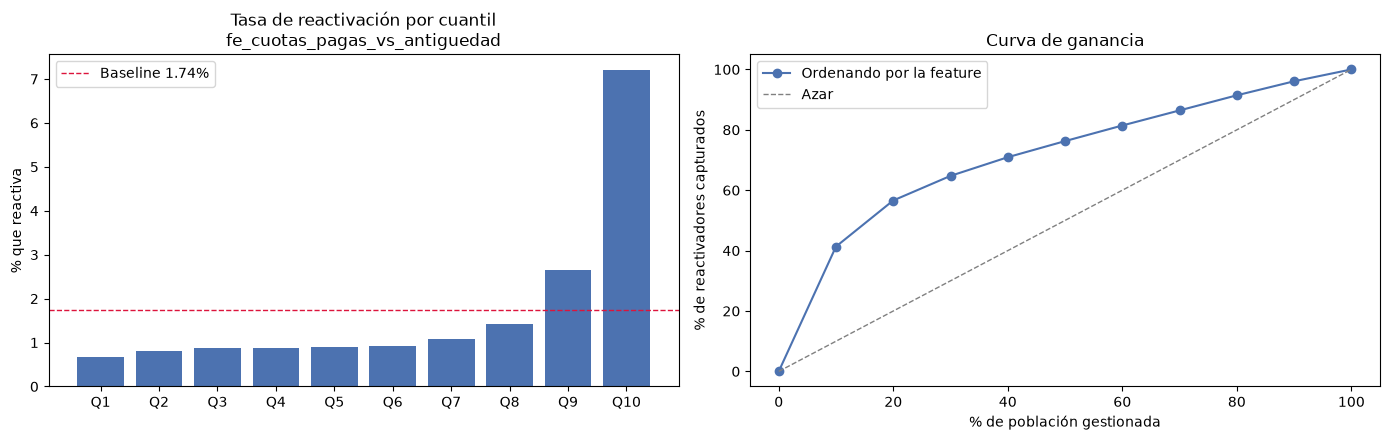

In [87]:
graficar_perfil(
    tbl, 
    feature='fe_cuotas_pagas_vs_antiguedad', 
    baseline_pct=1.74,
)